In [1]:
# Cell 1: imports + load base table
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from batch_physical_props import fetch_props_for_dataframe

DATA_DIR = Path("data")
waka_dragon_merged_df = pd.read_csv(DATA_DIR / "waka_dragon_merged.csv")
waka_dragon_merged_df.head()

,Unnamed: 0.1,Unnamed: 0,CID,CAS,Name,Imax,Ci,Di_x,intensity_class,MW,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,12,12,179,513-86-0,acetoin,49.69,0.90,0.76,1,88.12,...,54.205,92.70,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0.0
1,40,40,240,100-52-7,benzaldehyde,62.02,1.23,0.69,1,106.13,...,62.810,104.63,0.919,-2.89,-3.00,-3.00,1.0,34.0,0.000,0.0
2,42,42,244,100-51-6,benzyl alcohol,30.28,1.49,0.33,0,108.15,...,65.737,107.27,0.866,-2.74,-2.83,-2.82,1.0,34.0,0.000,0.0
3,89,89,323,91-64-5,coumarin,26.79,0.68,0.77,0,146.15,...,75.670,133.02,0.984,-3.32,-3.47,-3.49,3.0,56.0,0.000,0.0
4,90,90,326,122-03-2,cumin aldehyde,49.53,1.29,0.47,1,148.22,...,91.587,156.53,0.898,-3.70,-3.91,-3.95,1.0,50.0,0.033,0.0


In [2]:
# Cell 2: fetch boiling point and vapor pressure into a separate DF
# (no merge, no logging setup)

props_df = fetch_props_for_dataframe(
    waka_dragon_merged_df,
    cid_column="CID",
    delay_s=0.35,
    max_retries=4,
    retry_backoff_s=2.0,
    preferred_vp_temperature_c=25.0,
    cache_path=DATA_DIR / "pubchem_physical_props_cache.csv",
    resume=True,
)

props_df.head()

CID 6054: ConnectTimeout(MaxRetryError("HTTPSConnectionPool(host='pubchem.ncbi.nlm.nih.gov', port=443): Max retries exceeded with url: /rest/pug_view/data/compound/6054/JSON?heading=Vapor+Pressure (Caused by ConnectTimeoutError(<HTTPSConnection(host='pubchem.ncbi.nlm.nih.gov', port=443) at 0x1b8e1e8f9d0>, 'Connection to pubchem.ncbi.nlm.nih.gov timed out. (connect timeout=20)'))")) (attempt 1, sleeping 2.0s)


,cid,boiling_point_c,vapor_pressure_mmhg,error
0,179,147.500,2.690,
1,240,178.889,1.270,
2,244,205.500,0.094,
3,323,299.000,0.001,
4,326,235.500,NaN,


In [4]:
props_df.head(20)

,cid,boiling_point_c,vapor_pressure_mmhg,error
0,179,147.500,2.6900,
1,240,178.889,1.2700,
2,244,205.500,0.0940,
3,323,299.000,0.0010,
4,326,235.500,NaN,
5,454,171.000,0.6000,
6,798,130.500,0.0122,
7,957,195.000,0.0653,
8,1183,285.500,0.0001,
9,2345,323.500,0.0002,


In [6]:
# Cell 3: save standalone properties table
props_df.to_csv(DATA_DIR / "waka_pubchem_props_only.csv", index=False)
print(props_df.shape)

(312, 4)


In [7]:
# Cell 4: quick completeness checks
summary = {
    "n_rows": len(props_df),
    "n_unique_cids": props_df["cid"].nunique(),
    "bp_non_null": props_df["boiling_point_c"].notna().sum(),
    "vp_non_null": props_df["vapor_pressure_mmhg"].notna().sum(),
    "bp_missing_pct": round(props_df["boiling_point_c"].isna().mean() * 100, 2),
    "vp_missing_pct": round(props_df["vapor_pressure_mmhg"].isna().mean() * 100, 2),
    "fetch_errors": (props_df["error"].fillna("") != "").sum(),
}
summary

{'n_rows': 312,
 'n_unique_cids': 312,
 'bp_non_null': np.int64(192),
 'vp_non_null': np.int64(101),
 'bp_missing_pct': np.float64(38.46),
 'vp_missing_pct': np.float64(67.63),
 'fetch_errors': np.int64(0)}

In [8]:
# Cell 5: inspect missing/error rows
issues_df = props_df[
    props_df["boiling_point_c"].isna()
    | props_df["vapor_pressure_mmhg"].isna()
    | (props_df["error"].fillna("") != "")
].copy()

issues_df.head(20)

,cid,boiling_point_c,vapor_pressure_mmhg,error
4,326,235.5,NaN,
16,6501,273.5,NaN,
17,6532,229.0,NaN,
18,6548,NaN,0.010,
21,6631,NaN,NaN,
22,6660,NaN,NaN,
24,6874,277.5,NaN,
25,6986,NaN,NaN,
26,7007,NaN,NaN,
28,7122,300.5,NaN,


In [9]:
# Cell 6: basic stats
props_df[["boiling_point_c", "vapor_pressure_mmhg"]].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).T

,count,mean,std,min,5%,25%,50%,75%,95%,max
boiling_point_c,192.0,183.637729,66.890828,4.0,78.1000,126.075,189.0000,235.50,284.675,324.50
vapor_pressure_mmhg,101.0,5.344887,20.211683,0.0,0.0004,0.020,0.2163,1.55,25.400,171.18


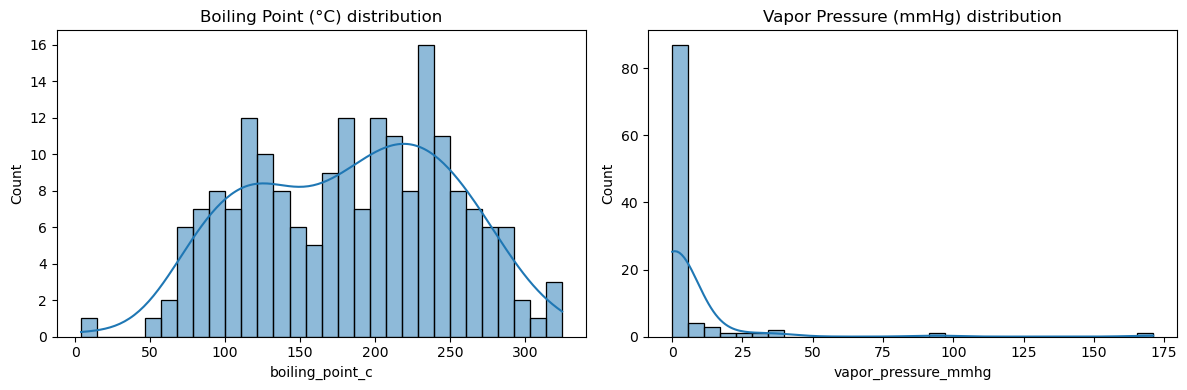

In [10]:
# Cell 7: distributions
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(props_df["boiling_point_c"].dropna(), bins=30, kde=True, ax=ax[0])
ax[0].set_title("Boiling Point (°C) distribution")
ax[0].set_xlabel("boiling_point_c")

sns.histplot(props_df["vapor_pressure_mmhg"].dropna(), bins=30, kde=True, ax=ax[1])
ax[1].set_title("Vapor Pressure (mmHg) distribution")
ax[1].set_xlabel("vapor_pressure_mmhg")

plt.tight_layout()
plt.show()